## 1. Importamos las librerías para el EDA


In [47]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Carga y exploración de la tabla principal: fact_viajes

In [48]:
# 1. Cargar el dataset desde la carpeta data
df_viajes = pd.read_csv('data/fact_viajes.csv')

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_viajes.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_viajes.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_viajes.tail())

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_viajes.sample(5))

--- Columnas y Tipos de Datos ---


viaje_id                    int64
linea_id                    int64
vehiculo_id                 int64
conductor_id                int64
parada_origen_id            int64
parada_destino_id           int64
fecha                         str
anno                        int64
mes                         int64
dia_semana                    str
es_festivo                   bool
franja_horaria                str
hora_salida_prog              str
hora_salida_real              str
hora_llegada_real             str
retraso_salida_min          int64
duracion_real_min           int64
pasajeros_subidos         float64
ocupacion_pct             float64
km_programados            float64
km_recorridos             float64
viaje_completado             bool
consumo                   float64
tarifa_predominante_id      int64
dtype: object

--- Primeras 5 filas (head) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,...,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,...,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,...,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,...,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,...,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


--- Ultimas 5 filas (tail) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
49995,49996,1,17,17,38,93,2024-09-23,2024,9,Monday,...,17:25,0,95,57.0,0.445,18.4,18.4,True,7.02,3
49996,49997,7,18,18,34,55,2023-06-28,2023,6,Wednesday,...,16:58,1,47,10.0,0.077,8.9,8.9,True,3.05,2
49997,49998,5,19,19,31,43,2023-02-05,2023,2,Sunday,...,06:51,3,28,98.0,0.754,7.3,7.3,True,2.23,2
49998,49999,1,20,20,12,114,2022-04-05,2022,4,Tuesday,...,22:23,2,91,118.0,0.944,18.4,18.4,True,7.11,3
49999,50000,9,21,21,1,77,2023-04-20,2023,4,Thursday,...,10:59,0,79,85.0,0.459,19.8,19.8,True,7.57,2


--- 5 filas aleatorias (sample) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
4499,4500,9,7,21,3,47,2024-09-03,2024,9,Tuesday,...,16:18,3,85,25.0,0.192,19.8,19.8,True,20.68,1
32530,32531,6,24,24,8,72,2022-09-02,2022,9,Friday,...,22:12,6,116,57.0,0.456,23.5,23.5,True,29.65,2
47685,47686,8,17,3,27,49,2024-09-29,2024,9,Sunday,...,13:11,3,68,71.0,0.555,12.6,12.6,True,4.67,1
22501,22502,4,33,19,20,106,2022-07-09,2022,7,Saturday,...,12:16,0,76,18.0,0.138,14.1,14.1,True,4.56,3
40410,40411,2,8,8,6,68,2023-06-14,2023,6,Wednesday,...,08:41,10,51,96.0,0.738,11.2,11.2,True,11.97,3


## 3. Análisis de valores nulos

In [49]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_viajes.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
porcentaje_nulos = (total_nulos / len(df_viajes)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en fact_viajes ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)



--- Resumen de Valores Nulos en fact_viajes ---


,Total Nulos,Porcentaje (%)
consumo,1065,2.13
pasajeros_subidos,40,0.08


#### Las dos columnas que tienen valosres nulos son 'consumo' y 'pasajeros'

### 3.1 Analizamos los valores nulos de manera más exhaustiva


In [50]:
# 1. Filtramos los viajes que no tienen registrado el consumo
nulos_consumo = df_viajes[df_viajes['consumo'].isnull()]

print("--- Top 5 Vehículos con fallos en el registro de 'consumo' ---")
# Contamos cuántos nulos tiene cada vehículo
display(nulos_consumo['vehiculo_id'].value_counts().head())
print("\n" + "="*60 + "\n")

# 2. Filtramos los viajes que no tienen registrado los pasajeros
nulos_pasajeros = df_viajes[df_viajes['pasajeros_subidos'].isnull()]

print("--- Top 5 Líneas con fallos en el registro de 'pasajeros' ---")
display(nulos_pasajeros['linea_id'].value_counts().head())
print("\n" + "="*60 + "\n")

# 3. Filtramos tambien por los vehiculos
print("\n--- Top 5 Vehículos con fallos en el registro de 'pasajeros' ---")
display(nulos_pasajeros['vehiculo_id'].value_counts().head())


--- Top 5 Vehículos con fallos en el registro de 'consumo' ---


vehiculo_id
23    110
39    107
9     105
37    102
7     102
Name: count, dtype: int64



--- Top 5 Líneas con fallos en el registro de 'pasajeros' ---


linea_id
5    7
9    7
6    5
8    4
1    4
Name: count, dtype: int64




--- Top 5 Vehículos con fallos en el registro de 'pasajeros' ---


vehiculo_id
20    3
26    3
9     2
5     2
23    2
Name: count, dtype: int64

#### En esta muestra encontramos que 2 de cada 5 vehiculos coinciden en nulos con las lineas

## 3.2 Estudiamos la interseción entre ambas columnas

In [51]:
col_consumo = 'consumo'
col_pasajeros = 'pasajeros_subidos'

# 1. Obtenemos la lista de todos los vehiculos que han fallado
vehiculos_consumo = set(df_viajes[df_viajes[col_consumo].isnull()]['vehiculo_id'].unique())
vehiculos_pasajeros = set(df_viajes[df_viajes[col_pasajeros].isnull()]['vehiculo_id'].unique())

# 2. Calculamos cuántos coinciden exactamente usando la intersección de conjuntos
interseccion_vehiculos = vehiculos_consumo.intersection(vehiculos_pasajeros)

# 3. Comprobamos cuantos fallan a la vez
interseccion_fallos = df_viajes[df_viajes[col_consumo].isnull() & df_viajes[col_pasajeros].isnull()]

print("--- RADIOGRAFÍA TOTAL DE FALLOS ---")
print(f"Total buses distintos con fallos de consumo: {len(vehiculos_consumo)}")
print(f"Total buses distintos con fallos de pasajeros: {len(vehiculos_pasajeros)}")
print(f"Buses que tienen AMBOS fallos: {len(interseccion_vehiculos)}")
print("-" * 35)
print(f"Total de VIAJES con fallo en consumo: {df_viajes[col_consumo].isnull().sum()}")
print(f"Total de VIAJES con fallo en pasajeros: {df_viajes[col_pasajeros].isnull().sum()}")
print(f"Viajes concretos donde fallaron AMBAS cosas a la vez: {len(interseccion_fallos)}")

--- RADIOGRAFÍA TOTAL DE FALLOS ---
Total buses distintos con fallos de consumo: 11
Total buses distintos con fallos de pasajeros: 26
Buses que tienen AMBOS fallos: 7
-----------------------------------
Total de VIAJES con fallo en consumo: 1065
Total de VIAJES con fallo en pasajeros: 40
Viajes concretos donde fallaron AMBAS cosas a la vez: 1


#### Se concluye que no existe relación técnica entre ambos fallos

## 3.3 Tratamiento de valores nulos

#### Para el tratamiento de los nulos de este dataset vamos a realizar la eliminación de todas las filas de la columna 'pasajeros' debido a que supone solo el 0.08 % del resultado total. En cambio, para la columna consumo haremos una media para rellenar esos valores nulos debido a que el porcentaje de los mismos asciente al 2.13%.

In [52]:
print(f"Filas antes de la limpieza: {len(df_viajes)}")

# 1. Borramos SOLO las filas donde 'pasajeros' es nulo
df_viajes = df_viajes.dropna(subset=['pasajeros_subidos'])
print(f"Filas después de la limpieza: {len(df_viajes)}")    

# 2. Calculamos el consumo mediano de toda la flota
consumo_mediana = df_viajes['consumo'].median()
print(f"Consumo mediano de la flota: {consumo_mediana}")

# 3. Rellenamos los nulos de 'consumo' con esa mediana
df_viajes ['consumo'] = df_viajes['consumo'].fillna(consumo_mediana)

print(f"Filas después de la limpieza: {len(df_viajes)}")
print("\n--- Comprobación final de nulos ---")
display(df_viajes[['consumo', 'pasajeros_subidos']].isnull().sum())


Filas antes de la limpieza: 50000
Filas después de la limpieza: 49960
Consumo mediano de la flota: 5.34
Filas después de la limpieza: 49960

--- Comprobación final de nulos ---


consumo              0
pasajeros_subidos    0
dtype: int64

In [53]:
# --- 1. TRATAMIENTO DE FECHAS Y HORAS ---

# 1.1. La columna 'fecha' la dejamos estricta porque sabemos que es Año-Mes-Día
df_viajes['fecha'] = pd.to_datetime(df_viajes['fecha'], format='%Y-%m-%d', errors='coerce')

# 1.2. Agrupamos solo las columnas con horas y les aplicamos el formato mixto
columnas_horas = [
    'hora_salida_prog', 
    'hora_salida_real', 
    'hora_llegada_real'
]

for col in columnas_horas:
    df_viajes[col] = pd.to_datetime(df_viajes[col], format='mixed', errors='coerce').dt.time


# --- 2. TRATAMIENTO DE MESES ---

traductor_meses = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

df_viajes['mes'] = df_viajes['mes'].map(traductor_meses)


# --- 3. COMPROBACIÓN FINAL ---

print("--- Comprobación de nulos en horas ---")
display(df_viajes[['hora_salida_prog', 'hora_salida_real', 'hora_llegada_real']].isnull().sum())

print("\n--- Muestra de los meses actualizados ---")
display(df_viajes[['fecha', 'hora_salida_prog', 'mes']].sample(5))

--- Comprobación de nulos en horas ---


hora_salida_prog     0
hora_salida_real     0
hora_llegada_real    0
dtype: int64


--- Muestra de los meses actualizados ---


,fecha,hora_salida_prog,mes
37957,2024-09-21,16:50:00,September
15943,2024-11-30,16:00:00,November
30491,2024-10-05,13:40:00,October
28374,2023-09-16,07:20:00,September
24670,2023-03-05,21:20:00,March


## 4 Estudio de outliers

### 4.1 Visualización de posibles columnas con outliers

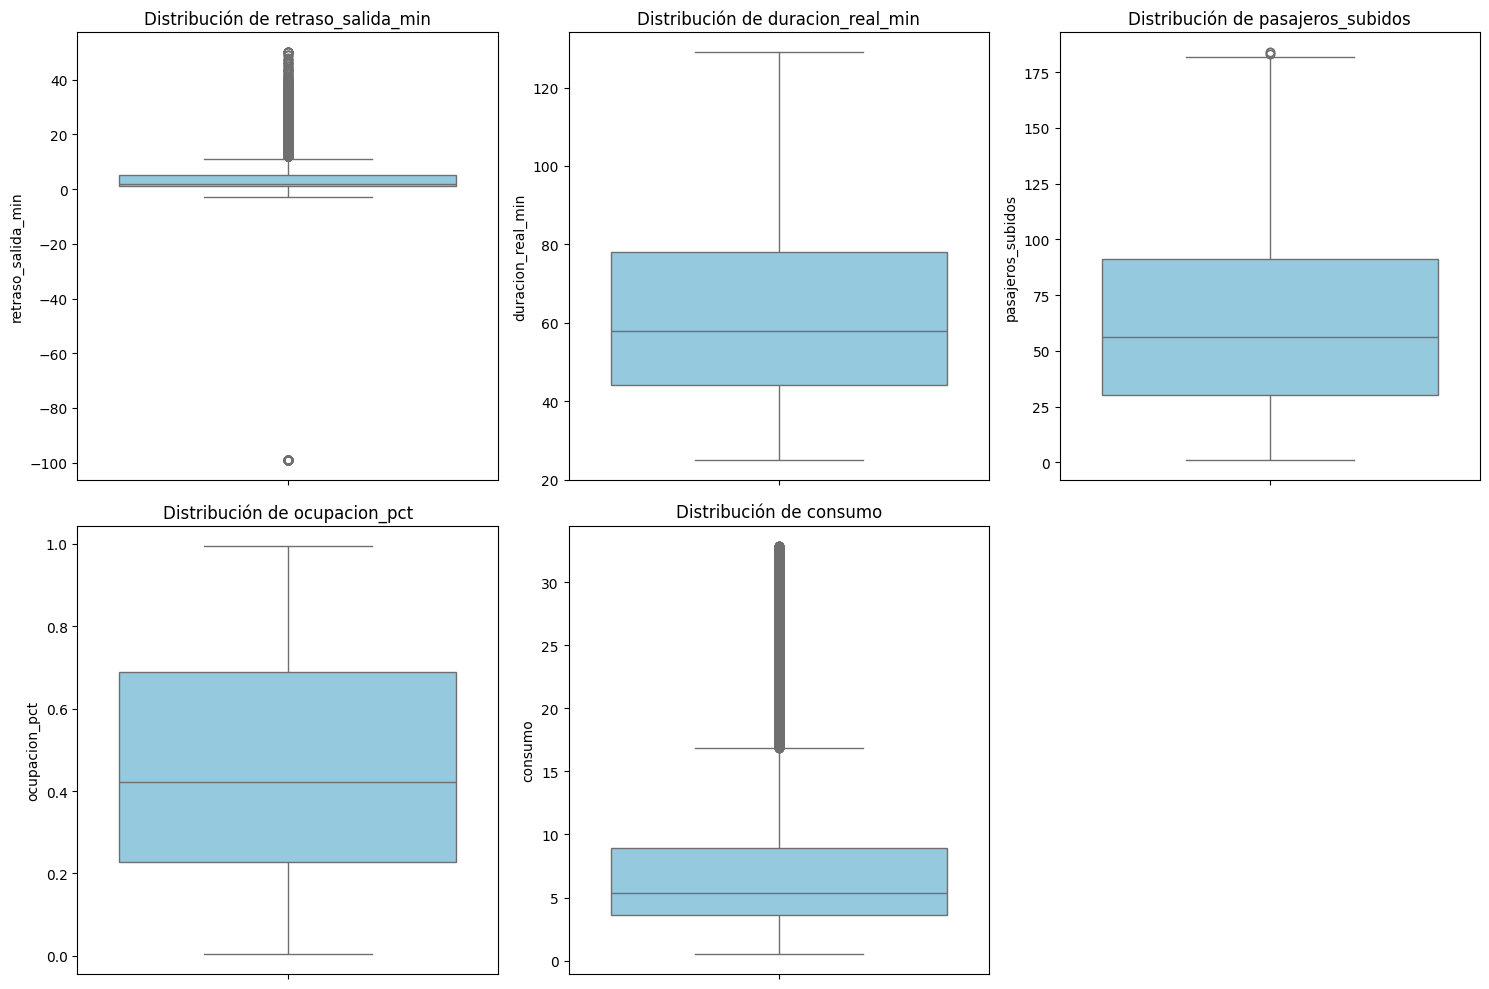


--- Resumen Estadístico de las variables clave ---


,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,consumo
count,49960.000000,49960.000000,49960.000000,49960.000000,49960.000000
mean,3.891253,62.598299,61.283907,0.455313,7.644995
std,6.763067,23.846471,36.847517,0.264234,6.164504
min,-99.000000,25.000000,1.000000,0.005000,0.550000
25%,1.000000,44.000000,30.000000,0.227000,3.630000
50%,2.000000,58.000000,56.000000,0.422000,5.340000
75%,5.000000,78.000000,91.000000,0.688000,8.930000
max,50.000000,129.000000,184.000000,0.995000,32.860000


In [55]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = [
    'retraso_salida_min', 
    'duracion_real_min', 
    'pasajeros_subidos', 
    'ocupacion_pct', 
    'consumo'
]

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_viajes[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_viajes[columnas_outliers].describe())

### 4.2 Tratamiento de Outliers (Limpieza y Winsorización)

In [ ]:
# --- 1. ELIMINACIÓN DEL ERROR FÍSICO (Retraso negativo extremo) ---

# Eliminamos de la tabla el viaje ilógico quedándonos con los mayores a -50
df_viajes = df_viajes[df_viajes['retraso_salida_min'] >= -50]
print(f"Filas tras borrar el error de salida anticipada: {len(df_viajes)}")


# --- 2. INVESTIGACIÓN DE ANOMALÍAS DE CONSUMO ---

# Calculamos la matemática del IQR para saber dónde está la frontera
Q1 = df_viajes['consumo'].quantile(0.25)
Q3 = df_viajes['consumo'].quantile(0.75)
IQR = Q3 - Q1
limite_superior_consumo = Q3 + 1.5 * IQR

print(f"\nFrontera máxima calculada para un consumo normal: {limite_superior_consumo:.2f}")

# Aislamos los viajes sospechosos en una tabla temporal
viajes_excesivos = df_viajes[df_viajes['consumo'] > limite_superior_consumo]

print(f"\nSe han detectado {len(viajes_excesivos)} viajes superando el límite.")

# --- 3. Buscamos un posible patrón en los vehículos ---

print("\n--- Top 5 Vehículos con más excesos de consumo ---")
# Contamos cuántas veces aparece cada vehículo en esta lista negra
vehiculos_infractores = viajes_excesivos['vehiculo_id'].value_counts().head(5)
display(vehiculos_infractores)

Filas tras borrar el error de salida anticipada: 49880

Frontera máxima calculada para un consumo normal: 16.88

Se han detectado 5109 viajes superando el límite.

--- Top 5 Vehículos con más excesos de consumo ---


vehiculo_id
8     505
38    483
37    476
29    471
22    471
Name: count, dtype: int64